# Unit08_Example_02 | 化工案例二：擴散係數之二維插值

本 Notebook 為 ChemE-3502「電腦在化工上之應用」課程 Unit08 的化工案例演練二。
以 **NO₂ 在 MDEA 水溶液中的擴散係數**隨溫度與濃度變化之實驗數據為例，
示範如何使用 `scipy.interpolate` 的二維插值方法，估算任意溫度與濃度下的擴散係數。

## 學習目標
- 理解二維插值的基本概念：雙變數（溫度、濃度）下的物性估算
- 使用 `scipy.interpolate.RegularGridInterpolator()` 進行規則網格二維插值
- 使用 `scipy.interpolate.RectBivariateSpline()` 進行二維樣條平滑插值
- 比較兩種方法在不同查詢點的插值結果差異
- 繪製二維等高線圖（Contour Plot）與三維曲面圖（3D Surface Plot）
- 以留存測試點定量驗證各方法的插值精確度

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Example_02'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_02
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_02\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy       版本: {np.__version__}")
import scipy
print(f"  scipy       版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib  版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy       版本: 1.23.5
  scipy       版本: 1.15.2
  matplotlib  版本: 3.10.8


---
### 2. 問題描述：NO₂ 在 MDEA 溶液中之擴散係數

#### 2.1 背景

**N-甲基二乙醇胺 (MDEA, N-methyldiethanolamine)** 是化工廠尾氣脫硫、脫碳製程中廣泛使用的液態吸收劑。
設計 SO₂ 或 NO₂ 化學吸收塔時，吸收劑中溶質的**擴散係數 (diffusion coefficient)** $D$ 是關鍵物性，
直接決定氣液傳質速率與塔高設計：

$$
N_A = k_L \cdot (C_A^* - C_{A,b}) = \frac{D}{H} \cdot (C_A^* - C_{A,b})
$$

其中 $k_L$ 為液膜傳質係數，$H$ 為液膜厚度。

$D$ 同時隨**溫度 $T$**（Arrhenius 關係）與**溶液濃度 $C$**（黏度效應）變化：

$$
D \propto \frac{T}{\mu(T, C)}
$$

由 Stokes-Einstein 方程式可知，$D$ 隨溫度升高而增大，隨 MDEA 濃度升高（溶液黏度增大）而降低。

#### 2.2 實驗數據（訓練數據點）

依據 N₂O 類比法（NO₂ 與 N₂O 的 $D$ 值在相同溶液中相近），
文獻量測 NO₂ 在不同溫度與 MDEA 濃度下的擴散係數（單位： $10^{-9}\ \mathrm{m^2/s}$ ）：

| $T$ (°C) ↓ / $C_\text{MDEA}$ (wt%) → | 10% | 20% | 30% | 40% | 50% |
|:---:|:---:|:---:|:---:|:---:|:---:|
| **25** | 2.01 | 1.65 | 1.29 | 0.91 | 0.59 |
| **30** | 2.43 | 1.99 | 1.55 | 1.10 | 0.71 |
| **35** | 2.91 | 2.38 | 1.86 | 1.32 | 0.85 |
| **40** | 3.46 | 2.83 | 2.21 | 1.57 | 1.01 |
| **45** | 4.08 | 3.34 | 2.61 | 1.86 | 1.19 |
| **50** | 4.78 | 3.91 | 3.06 | 2.18 | 1.40 |

#### 2.3 問題目標

1. 使用 `RegularGridInterpolator` 與 `RectBivariateSpline` 建立二維插值函數
2. 估算任意 $(T, C)$ 組合下的擴散係數（例如 $T = 37$ °C、$C = 25$ wt%）
3. 繪製二維等高線圖與三維曲面圖，視覺化 $D(T, C)$ 的分布特徵
4. 以留存測試點驗證插值精確度

#### 2.4 精確度驗證用數據（測試數據點）

| $T$ (°C) | $C_\text{MDEA}$ (wt%) | $D_\text{true}$ ( $10^{-9}\ \mathrm{m^2/s}$ ) |
|:---:|:---:|:---:|
| 27 | 25 | 1.60 |
| 38 | 15 | 2.94 |
| 47 | 45 | 1.67 |

In [3]:
# ============================================================
# 數據定義
# ============================================================

# 訓練數據：網格軸定義
T_grid = np.array([25.0, 30.0, 35.0, 40.0, 45.0, 50.0])   # 溫度 (°C)
C_grid = np.array([10.0, 20.0, 30.0, 40.0, 50.0])           # MDEA 濃度 (wt%)

# 擴散係數矩陣 D[i, j] = D at T_grid[i], C_grid[j]
# 單位：1e-9 m²/s
D_data = np.array([
    [2.01, 1.65, 1.29, 0.91, 0.59],   # T = 25 °C
    [2.43, 1.99, 1.55, 1.10, 0.71],   # T = 30 °C
    [2.91, 2.38, 1.86, 1.32, 0.85],   # T = 35 °C
    [3.46, 2.83, 2.21, 1.57, 1.01],   # T = 40 °C
    [4.08, 3.34, 2.61, 1.86, 1.19],   # T = 45 °C
    [4.78, 3.91, 3.06, 2.18, 1.40],   # T = 50 °C
])

# 測試數據點（精確度驗證用，由 Arrhenius + 線性濃度插值得到）
T_test = np.array([27.0, 38.0, 47.0])           # 溫度 (°C)
C_test = np.array([25.0, 15.0, 45.0])           # 濃度 (wt%)
D_test_true = np.array([1.60, 2.94, 1.67])      # 真實值 (1e-9 m²/s)

# 顯示訓練數據
print("=" * 62)
print("  訓練數據 — D (NO₂/MDEA) 單位: 1e-9 m²/s")
print("=" * 62)
header = f"  {'T(°C)':>6}"
for c in C_grid:
    header += f"  {int(c):>4}wt%"
print(header)
print("-" * 62)
for i, t in enumerate(T_grid):
    row = f"  {t:>5.0f}°C"
    for j in range(len(C_grid)):
        row += f"   {D_data[i, j]:>5.2f}"
    print(row)
print()
print("=" * 55)
print("  測試數據點（精確度驗證用）")
print("=" * 55)
print(f"  {'T (°C)':>7} {'C (wt%)':>8} {'D_true (1e-9 m²/s)':>20}")
print("-" * 42)
for t, c, d in zip(T_test, C_test, D_test_true):
    print(f"  {t:>7.1f} {c:>8.1f} {d:>20.2f}")

  訓練數據 — D (NO₂/MDEA) 單位: 1e-9 m²/s
   T(°C)    10wt%    20wt%    30wt%    40wt%    50wt%
--------------------------------------------------------------
     25°C    2.01    1.65    1.29    0.91    0.59
     30°C    2.43    1.99    1.55    1.10    0.71
     35°C    2.91    2.38    1.86    1.32    0.85
     40°C    3.46    2.83    2.21    1.57    1.01
     45°C    4.08    3.34    2.61    1.86    1.19
     50°C    4.78    3.91    3.06    2.18    1.40

  測試數據點（精確度驗證用）
   T (°C)  C (wt%)   D_true (1e-9 m²/s)
------------------------------------------
     27.0     25.0                 1.60
     38.0     15.0                 2.94
     47.0     45.0                 1.67


---
### 3. 建立二維插值函數

#### 3.1 `RegularGridInterpolator`

用於**規則網格**（即 $T$ 軸與 $C$ 軸均為固定間隔或不規則但各自有序的向量）的二維插值：

```python
from scipy.interpolate import RegularGridInterpolator
f = RegularGridInterpolator((T_grid, C_grid), D_data, method='linear')
D_query = f([[T1, C1], [T2, C2]])  # 批次查詢
```

支援方法（`method` 參數）：

| `method` | 說明 |
|:---:|:---|
| `'nearest'` | 最近鄰插值，結果為階梯面 |
| `'linear'` | 雙線性插值（bilinear），分段線性拼接 |
| `'slinear'` | 等效於 linear（向量形式） |
| `'cubic'` | 雙三次插值（bicubic），C² 平滑曲面 |
| `'quintic'` | 雙五次插值，更高階平滑 |

> 預設邊界行為：`bounds_error=True`，查詢點不得超出網格範圍。

#### 3.2 `RectBivariateSpline`

針對規則矩形網格的**二維樣條插值**，以整體最小化方式求解樣條係數，
可控制平滑程度（`kx`, `ky` 為各方向樣條階數，`s` 為平滑因子）：

```python
from scipy.interpolate import RectBivariateSpline
f = RectBivariateSpline(T_grid, C_grid, D_data, kx=3, ky=3, s=0)
D_query = f(T_query_1d, C_query_1d)  # 注意：輸出為矩陣
D_point = f(T1, C1, grid=False)       # 查詢單點或向量時設 grid=False
```

| 參數 | 說明 |
|:---:|:---|
| `kx`, `ky` | $T$ 與 $C$ 方向的樣條階數（預設 3 = 三次樣條） |
| `s=0` | 平滑因子為 0 = 嚴格通過所有數據點（插值模式）|
| `s>0` | 允許殘差以平滑曲面（近似/迴歸模式）|

> **RectBivariateSpline 與 RegularGridInterpolator (cubic) 的差異**：
> 前者為全域整體優化樣條，後者為逐段雙三次多項式拼接。
> 數據點數量足夠多時兩者結果相近；數據稀疏時 RectBivariateSpline 平滑性更佳。

In [4]:
# ============================================================
# 建立二維插值函數
# ============================================================

# (1) RegularGridInterpolator — 雙線性插值
f_rgi_linear = RegularGridInterpolator(
    (T_grid, C_grid), D_data, method='linear', bounds_error=True
)

# (2) RegularGridInterpolator — 雙三次插值
f_rgi_cubic = RegularGridInterpolator(
    (T_grid, C_grid), D_data, method='cubic', bounds_error=True
)

# (3) RectBivariateSpline — 三次樣條插值 (s=0 嚴格插值模式)
f_rbs = RectBivariateSpline(T_grid, C_grid, D_data, kx=3, ky=3, s=0)

# ============================================================
# 在測試點查詢插值結果
# ============================================================
query_pts = np.column_stack([T_test, C_test])  # shape (3, 2)

D_rgi_lin = f_rgi_linear(query_pts)
D_rgi_cub = f_rgi_cubic(query_pts)
D_rbs_val = f_rbs(T_test, C_test, grid=False)

# ============================================================
# 顯示比較表
# ============================================================
print("=" * 78)
print("  二維插值結果比較（單位：1e-9 m²/s）")
print("=" * 78)
print(f"  {'T(°C)':>6} {'C(wt%)':>7} {'True D':>8}  {'RGI-Linear':>11} {'RGI-Cubic':>10} {'RBS-Cubic':>10}")
print("-" * 78)
for i in range(len(T_test)):
    print(f"  {T_test[i]:>6.1f} {C_test[i]:>7.1f} {D_test_true[i]:>8.2f}  "
          f"{D_rgi_lin[i]:>11.4f} {D_rgi_cub[i]:>10.4f} {D_rbs_val[i]:>10.4f}")
print()
print("=" * 78)
print("  絕對誤差（|D_interp - D_true|）")
print("=" * 78)
print(f"  {'T(°C)':>6} {'C(wt%)':>7} {'True D':>8}  {'RGI-Linear':>11} {'RGI-Cubic':>10} {'RBS-Cubic':>10}")
print("-" * 78)
for i in range(len(T_test)):
    print(f"  {T_test[i]:>6.1f} {C_test[i]:>7.1f} {D_test_true[i]:>8.2f}  "
          f"{abs(D_rgi_lin[i]-D_test_true[i]):>11.4f} "
          f"{abs(D_rgi_cub[i]-D_test_true[i]):>10.4f} "
          f"{abs(D_rbs_val[i]-D_test_true[i]):>10.4f}")

  二維插值結果比較（單位：1e-9 m²/s）
   T(°C)  C(wt%)   True D   RGI-Linear  RGI-Cubic  RBS-Cubic
------------------------------------------------------------------------------
    27.0    25.0     1.60       1.5900     1.5860     1.5860
    38.0    15.0     2.94       2.9450     2.9318     2.9318
    47.0    45.0     1.67       1.6310     1.6084     1.6083

  絕對誤差（|D_interp - D_true|）
   T(°C)  C(wt%)   True D   RGI-Linear  RGI-Cubic  RBS-Cubic
------------------------------------------------------------------------------
    27.0    25.0     1.60       0.0100     0.0140     0.0140
    38.0    15.0     2.94       0.0050     0.0082     0.0082
    47.0    45.0     1.67       0.0390     0.0616     0.0617


---
### 4. 二維等高線圖比較

以等高線圖（Contour Plot）視覺化三種插值方法在整個 $(T, C)$ 網格上的 $D$ 分布，
並標示訓練數據點與測試點。

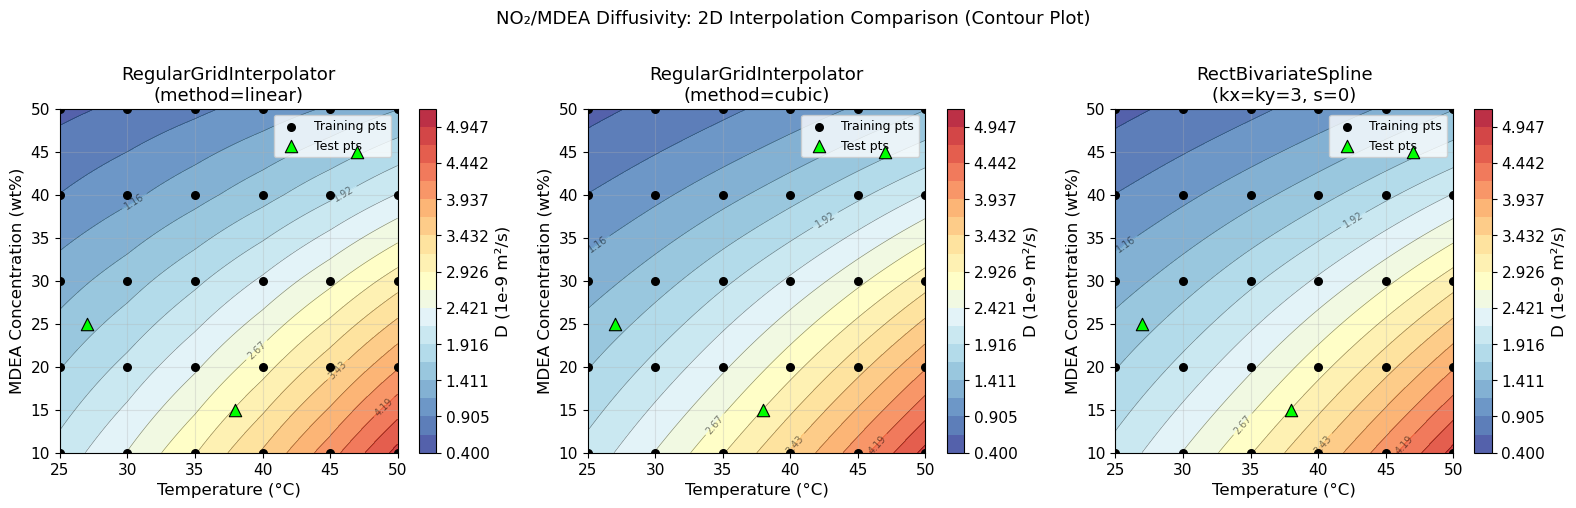

✓ 圖片已儲存


In [5]:
# ============================================================
# 建立細密查詢網格
# ============================================================
T_fine = np.linspace(T_grid.min(), T_grid.max(), 200)
C_fine = np.linspace(C_grid.min(), C_grid.max(), 200)
TT, CC = np.meshgrid(T_fine, C_fine, indexing='ij')

# 產生各方法的插值面
pts_2d = np.column_stack([TT.ravel(), CC.ravel()])
D_lin_surface  = f_rgi_linear(pts_2d).reshape(TT.shape)
D_cub_surface  = f_rgi_cubic(pts_2d).reshape(TT.shape)
D_rbs_surface  = f_rbs(T_fine, C_fine, grid=True)

# ============================================================
# 三圖並排等高線圖
# ============================================================
levels = np.linspace(0.4, 5.2, 20)
cmap = 'RdYlBu_r'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['RegularGridInterpolator\n(method=linear)',
          'RegularGridInterpolator\n(method=cubic)',
          'RectBivariateSpline\n(kx=ky=3, s=0)']
surfaces = [D_lin_surface, D_cub_surface, D_rbs_surface]

# Training data meshgrid for scatter
TT_train, CC_train = np.meshgrid(T_grid, C_grid, indexing='ij')

for ax, surf, title in zip(axes, surfaces, titles):
    cf = ax.contourf(TT, CC, surf, levels=levels, cmap=cmap, alpha=0.85)
    cs = ax.contour(TT, CC, surf, levels=levels, colors='k', linewidths=0.4, alpha=0.5)
    ax.clabel(cs, cs.levels[::3], inline=True, fontsize=7, fmt='%.2f')
    ax.scatter(TT_train.ravel(), CC_train.ravel(), s=30, c='k', marker='o',
               zorder=5, label='Training pts')
    ax.scatter(T_test, C_test, s=80, c='lime', marker='^', edgecolors='k',
               linewidths=0.8, zorder=6, label='Test pts')
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('MDEA Concentration (wt%)')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=9)
    plt.colorbar(cf, ax=ax, label='D (1e-9 m²/s)')

plt.suptitle('NO₂/MDEA Diffusivity: 2D Interpolation Comparison (Contour Plot)',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_contour_comparison.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
### 5. 三維曲面圖

以三維曲面圖（3D Surface Plot）比較 RGI-Linear（雙線性）與 RBS-Cubic（雙三次樣條）的差異，
直觀呈現線性插值在網格邊界處的折角與三次樣條的平滑連續性。

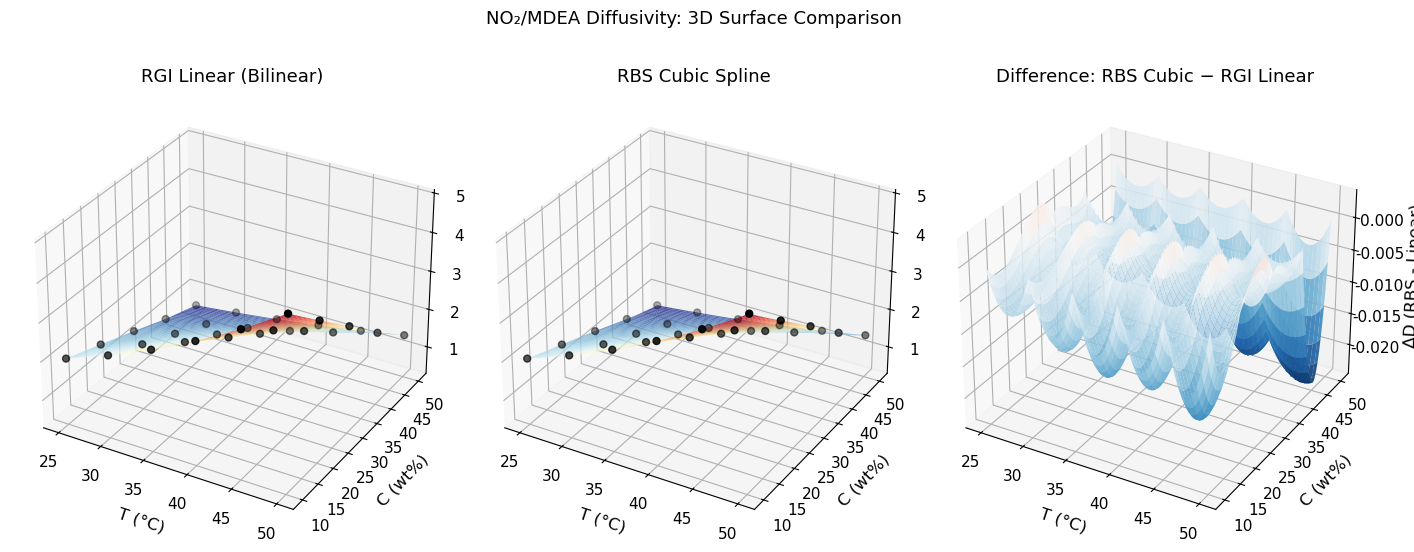

✓ 圖片已儲存


In [6]:
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401

fig = plt.figure(figsize=(14, 6))

plot_data = [
    (D_lin_surface, 'RGI Linear (Bilinear)', 131),
    (D_rbs_surface, 'RBS Cubic Spline', 132),
]

for surf, title, subplot_idx in plot_data:
    ax = fig.add_subplot(subplot_idx, projection='3d')
    ax.plot_surface(TT, CC, surf, cmap='RdYlBu_r', alpha=0.85, linewidth=0)
    ax.scatter(TT_train.ravel(), CC_train.ravel(), D_data.ravel(),
               c='k', s=25, zorder=5, label='Training data')
    ax.set_xlabel('T (°C)', labelpad=6)
    ax.set_ylabel('C (wt%)', labelpad=6)
    ax.set_zlabel('D (1e-9 m²/s)', labelpad=6)
    ax.set_title(title, pad=8)

# 差值圖（RBS - RGI_linear）
ax3 = fig.add_subplot(133, projection='3d')
diff_surf = D_rbs_surface - D_lin_surface
vmax = np.abs(diff_surf).max()
ax3.plot_surface(TT, CC, diff_surf, cmap='RdBu_r', alpha=0.9,
                 vmin=-vmax, vmax=vmax, linewidth=0)
ax3.set_xlabel('T (°C)', labelpad=6)
ax3.set_ylabel('C (wt%)', labelpad=6)
ax3.set_zlabel('ΔD (RBS - Linear)', labelpad=6)
ax3.set_title('Difference: RBS Cubic − RGI Linear', pad=8)

plt.suptitle('NO₂/MDEA Diffusivity: 3D Surface Comparison', fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_surface_3d.png', bbox_inches='tight', dpi=120)
plt.show()
print("✓ 圖片已儲存")

---
### 6. 精確度驗證

以三個離網格的測試點（ $(T, C) = (27, 25), (38, 15), (47, 45)$ ）
評估各方法的插值精確度。

定義**相對誤差**（百分比）：

$$\text{相對誤差} = \frac{|D_{\text{interp}} - D_{\text{true}}|}{D_{\text{true}}} \times 100\%$$

> 測試點的「真實值」由 Arrhenius 方程式與線性濃度插值計算所得，
> 可視為本數據集在該點最合理的物理估計值。

  精確度驗證結果（相對誤差 %）
   T(°C)  C(wt%)   True D   RGI-Linear    RGI-Cubic    RBS-Cubic
---------------------------------------------------------------------------
    27.0    25.0     1.60        0.63%        0.87%        0.88%
    38.0    15.0     2.94        0.17%        0.28%        0.28%
    47.0    45.0     1.67        2.34%        3.69%        3.70%

  平均絕對相對誤差 (MARE):
      RGI-Linear: 1.04%
       RGI-Cubic: 1.61%
       RBS-Cubic: 1.62%


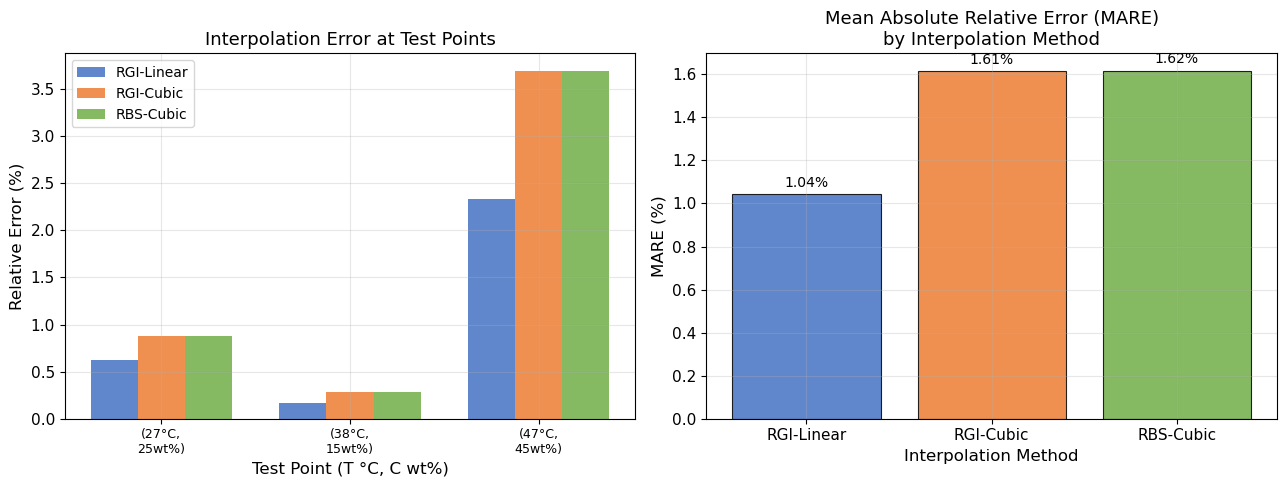


✓ 圖片已儲存

✅  Unit08_Example_02 全部完成！


In [7]:
# ============================================================
# 精確度驗證：相對誤差計算與比較圖
# ============================================================

methods_dict = {
    'RGI-Linear': D_rgi_lin,
    'RGI-Cubic':  D_rgi_cub,
    'RBS-Cubic':  D_rbs_val,
}

print("=" * 75)
print("  精確度驗證結果（相對誤差 %）")
print("=" * 75)
print(f"  {'T(°C)':>6} {'C(wt%)':>7} {'True D':>8}", end="")
for name in methods_dict:
    print(f"  {name:>11}", end="")
print()
print("-" * 75)

for i in range(len(T_test)):
    print(f"  {T_test[i]:>6.1f} {C_test[i]:>7.1f} {D_test_true[i]:>8.2f}", end="")
    for vals in methods_dict.values():
        rel_err = abs(vals[i] - D_test_true[i]) / D_test_true[i] * 100
        print(f"  {rel_err:>10.2f}%", end="")
    print()

print()
print("  平均絕對相對誤差 (MARE):")
for name, vals in methods_dict.items():
    mare = np.mean(np.abs(vals - D_test_true) / D_test_true * 100)
    print(f"    {name:>12}: {mare:.2f}%")

# ============================================================
# 精確度比較長條圖
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#4472C4', '#ED7D31', '#70AD47']
method_names = list(methods_dict.keys())
x = np.arange(len(T_test))
width = 0.25

# 左圖：各測試點相對誤差
ax1 = axes[0]
for k, (name, vals) in enumerate(methods_dict.items()):
    rel_errs = np.abs(vals - D_test_true) / D_test_true * 100
    ax1.bar(x + k * width, rel_errs, width, label=name, color=colors[k], alpha=0.85)
ax1.set_xlabel('Test Point (T °C, C wt%)')
ax1.set_ylabel('Relative Error (%)')
ax1.set_title('Interpolation Error at Test Points')
ax1.set_xticks(x + width)
ax1.set_xticklabels([f'({int(t)}°C,\n{int(c)}wt%)'
                     for t, c in zip(T_test, C_test)], fontsize=9)
ax1.legend()

# 右圖：MARE 長條圖
ax2 = axes[1]
mare_vals = [np.mean(np.abs(v - D_test_true) / D_test_true * 100)
             for v in methods_dict.values()]
bars = ax2.bar(method_names, mare_vals, color=colors, alpha=0.85,
               edgecolor='k', linewidth=0.8)
for bar, val in zip(bars, mare_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10)
ax2.set_xlabel('Interpolation Method')
ax2.set_ylabel('MARE (%)')
ax2.set_title('Mean Absolute Relative Error (MARE)\nby Interpolation Method')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_accuracy_comparison.png', bbox_inches='tight')
plt.show()
print("\n✓ 圖片已儲存")
print("\n✅  Unit08_Example_02 全部完成！")